# 05 — Model Interpretability (SHAP, LIME & Factor Decomposition)

The course guidelines separate *modeling* notebooks from a dedicated *interpretability* notebook. This notebook collects every explanation for the project in one place, for **both** recommenders:

- **Part A — Content-Based model** (from `03_content_based_filtering_embeddings.ipynb`): a surrogate Random Forest on TF-IDF features explained with **SHAP**, plus word-level **LIME**.
- **Part B — Collaborative Filtering model** (from `04_collaborative_filtering.ipynb`): the SGD matrix-factorization model explained by **exact additive factor decomposition** (rendered as a SHAP waterfall) and neighbour-based reasons.

> Numbering note: `04` is the collaborative-filtering *modeling* notebook, so interpretability is `05`.


## Setup — imports, data, embeddings

Copied from notebook 03 so this notebook runs top-to-bottom on its own. On a fresh checkout the embeddings cache may be rebuilt on first run (downloads `all-MiniLM-L6-v2`, a few minutes).

In [6]:
import sys
from pathlib import Path

# Make `src/` importable from the notebook
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from lime import lime_text
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Project modules (split out of the notebook for clarity)
from src.content_based.embeddings import build_or_load_embeddings
from src.content_based.evaluation import catalog_coverage, intra_list_diversity, precision_at_k
from src.content_based.explainability import extract_class_shap, make_lime_predict_fn
from src.content_based.recommender import build_title_to_index, get_recommendations, recommend_for_user

warnings.filterwarnings("ignore")

SEED = 42
plt.rcParams["figure.dpi"] = 110

print("All imports OK")

All imports OK


In [7]:
DATA_PATH = "../data/raw/"

movies = pd.read_csv(
    DATA_PATH + "movies.dat",
    sep="\t",
    encoding="latin-1",
    usecols=[0, 1, 5],
    names=[
        "movieID",
        "title",
        "imdbID",
        "spanishTitle",
        "imdbPictureURL",
        "year",
        "rtID",
        "rtAllCriticsRating",
        "rtAllCriticsNumReviews",
        "rtAllCriticsNumFresh",
        "rtAllCriticsNumRotten",
        "rtAllCriticsScore",
        "rtTopCriticsRating",
        "rtTopCriticsNumReviews",
        "rtTopCriticsNumFresh",
        "rtTopCriticsNumRotten",
        "rtTopCriticsScore",
        "rtAudienceRating",
        "rtAudienceNumRatings",
        "rtAudienceScore",
        "rtPictureURL",
    ],
    header=0,
)

movie_genres = pd.read_csv(
    DATA_PATH + "movie_genres.dat", sep="\t", encoding="latin-1", header=0, names=["movieID", "genre"]
)

movie_directors = pd.read_csv(
    DATA_PATH + "movie_directors.dat",
    sep="\t",
    encoding="latin-1",
    header=0,
    names=["movieID", "directorID", "directorName"],
)

movie_actors = pd.read_csv(
    DATA_PATH + "movie_actors.dat",
    sep="\t",
    encoding="latin-1",
    header=0,
    names=["movieID", "actorID", "actorName", "ranking"],
)

movie_tags = pd.read_csv(
    DATA_PATH + "movie_tags.dat", sep="\t", encoding="latin-1", header=0, names=["movieID", "tagID", "tagWeight"]
)

tags = pd.read_csv(DATA_PATH + "tags.dat", sep="\t", encoding="latin-1", header=0, names=["tagID", "tagValue"])

ratings = pd.read_csv(
    DATA_PATH + "user_ratedmovies.dat",
    sep="\t",
    encoding="latin-1",
    header=0,
    usecols=[0, 1, 2],
    names=[
        "userID",
        "movieID",
        "rating",
        "date_day",
        "date_month",
        "date_year",
        "date_hour",
        "date_minute",
        "date_second",
    ],
)

print(f"Movies:    {len(movies):>7,}")
print(f"Genres:    {len(movie_genres):>7,}")
print(f"Directors: {len(movie_directors):>7,}")
print(f"Actors:    {len(movie_actors):>7,}")
print(f"Tags:      {len(movie_tags):>7,}")
print(f"Ratings:   {len(ratings):>7,}")

Movies:     10,197
Genres:     20,809
Directors:  10,155
Actors:    231,742
Tags:       51,795
Ratings:   855,598


In [8]:
# Genres per movie
genres_grouped = (
    movie_genres.groupby("movieID")["genre"]
    .apply(lambda x: " ".join(x.str.replace(" ", "_")))
    .reset_index()
    .rename(columns={"genre": "genres_str"})
)

# Director per movie
director_grouped = movie_directors.groupby("movieID")["directorName"].first().reset_index()
director_grouped["directorName"] = director_grouped["directorName"].str.replace(" ", "_").str.lower()

# Top-5 actors per movie
top_actors = (
    movie_actors[movie_actors["ranking"] <= 5]
    .groupby("movieID")["actorName"]
    .apply(lambda x: " ".join(x.str.replace(" ", "_").str.lower()))
    .reset_index()
    .rename(columns={"actorName": "actors_str"})
)

# Top-10 tags per movie (by weight)
movie_tags_named = movie_tags.merge(tags, on="tagID", how="left")
top_tags = (
    movie_tags_named.sort_values(["movieID", "tagWeight"], ascending=[True, False])
    .groupby("movieID")
    .head(10)
    .groupby("movieID")["tagValue"]
    .apply(lambda x: " ".join(x.astype(str).str.replace(" ", "_").str.lower()))
    .reset_index()
    .rename(columns={"tagValue": "tags_str"})
)

# Merge into one profile per movie
movie_profiles = movies[["movieID", "title", "year"]].copy()
movie_profiles = movie_profiles.merge(genres_grouped, on="movieID", how="left")
movie_profiles = movie_profiles.merge(director_grouped, on="movieID", how="left")
movie_profiles = movie_profiles.merge(top_actors, on="movieID", how="left")
movie_profiles = movie_profiles.merge(top_tags, on="movieID", how="left")

for col in ["genres_str", "directorName", "actors_str", "tags_str"]:
    movie_profiles[col] = movie_profiles[col].fillna("")

# content_soup: genres doubled for extra weight
movie_profiles["content_soup"] = (
    movie_profiles["genres_str"]
    + " "
    + movie_profiles["genres_str"]
    + " "
    + movie_profiles["directorName"]
    + " "
    + movie_profiles["actors_str"]
    + " "
    + movie_profiles["tags_str"]
).str.strip()

# Remove empty profiles
movie_profiles_clean = movie_profiles[movie_profiles["content_soup"].str.len() > 0].copy()
movie_profiles_clean = movie_profiles_clean.reset_index(drop=True)

print(f"Movies with profiles: {len(movie_profiles_clean)}")
print()
ex = movie_profiles_clean.iloc[0]
print(f"Title: {ex['title']}")
print(f"Soup:  {ex['content_soup'][:180]}...")

Movies with profiles: 10197

Title: Toy story
Soup:  Adventure Animation Children Comedy Fantasy Adventure Animation Children Comedy Fantasy john_lasseter don_rickles jim_varney tim_allen tom_hanks wallace_shawn animation pixar disne...


In [9]:
CACHE = Path("../data/processed/movie_embeddings.npy")

embeddings = build_or_load_embeddings(
    soups=movie_profiles_clean["content_soup"].tolist(),
    cache_path=CACHE,
    model_name="all-MiniLM-L6-v2",
    batch_size=64,
)

print(f"Embedding shape: {embeddings.shape}")  # (10197, 384)
print(f"L2-normalised:   norm[0] = {np.linalg.norm(embeddings[0]):.4f}")

Batches: 100%|██████████| 160/160 [01:57<00:00,  1.36it/s]


Embedding shape: (10197, 384)
L2-normalised:   norm[0] = 1.0000


In [10]:
title_to_index = build_title_to_index(movie_profiles_clean)
print(f"{len(title_to_index)} unique titles indexed.")

9406 unique titles indexed.


# Part A — Content-Based Model

Cosine similarity between 384-dim sentence embeddings is not human-readable, so we train an **interpretable surrogate**: a Random Forest that predicts whether a movie is in the top-100 most similar to a query movie, using **word-level TF-IDF** features. Explaining that surrogate reveals *which words* drive the recommendations.

## A1 — SHAP

### Build labels, TF-IDF features, and the surrogate Random Forest

In [11]:
# --- 7a. Build binary labels ---
# A movie is labelled 1 if it is in the top-100 most similar to the query movie

QUERY = "Toy story"
query_idx = title_to_index[QUERY]
sim_scores = embeddings @ embeddings[query_idx]
threshold = np.sort(sim_scores)[::-1][100]  # 101st score
y_labels = (sim_scores >= threshold).astype(int)

print(f'Query movie: "{QUERY}"')
print(f"Positive (similar) movies:  {y_labels.sum()}")
print(f"Negative (rest):            {(y_labels == 0).sum()}")

Query movie: "Toy story"
Positive (similar) movies:  101
Negative (rest):            10096


In [12]:
# --- 7b. TF-IDF features (interpretable word-level) ---
tfidf = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf.fit_transform(movie_profiles_clean["content_soup"]).toarray()
feature_names = tfidf.get_feature_names_out()

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_labels, test_size=0.2, random_state=SEED, stratify=y_labels
)

# --- 7c. Train surrogate Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test), target_names=["not_similar", "similar"]))

              precision    recall  f1-score   support

 not_similar       0.99      1.00      1.00      2020
     similar       1.00      0.20      0.33        20

    accuracy                           0.99      2040
   macro avg       1.00      0.60      0.66      2040
weighted avg       0.99      0.99      0.99      2040



In [13]:
# --- 7d. SHAP TreeExplainer ---
explainer = shap.TreeExplainer(rf)
X_shap = X_test[:300]
shap_values = explainer.shap_values(X_shap, check_additivity=False)

# Helper handles all SHAP version differences (list vs 3D ndarray)
sv_c1, base_c1 = extract_class_shap(shap_values, explainer.expected_value, class_idx=1)
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

assert sv_c1.shape == X_shap_df.shape, f"shape mismatch sv_c1={sv_c1.shape} X_shap_df={X_shap_df.shape}"

print(f"sv_c1 shape:      {sv_c1.shape}")
print(f"X_shap_df shape:  {X_shap_df.shape}")
print(f"Base value:       {base_c1:.4f}")

sv_c1 shape:      (300, 2000)
X_shap_df shape:  (300, 2000)
Base value:       0.0098


### A1.1 — Beeswarm summary plot

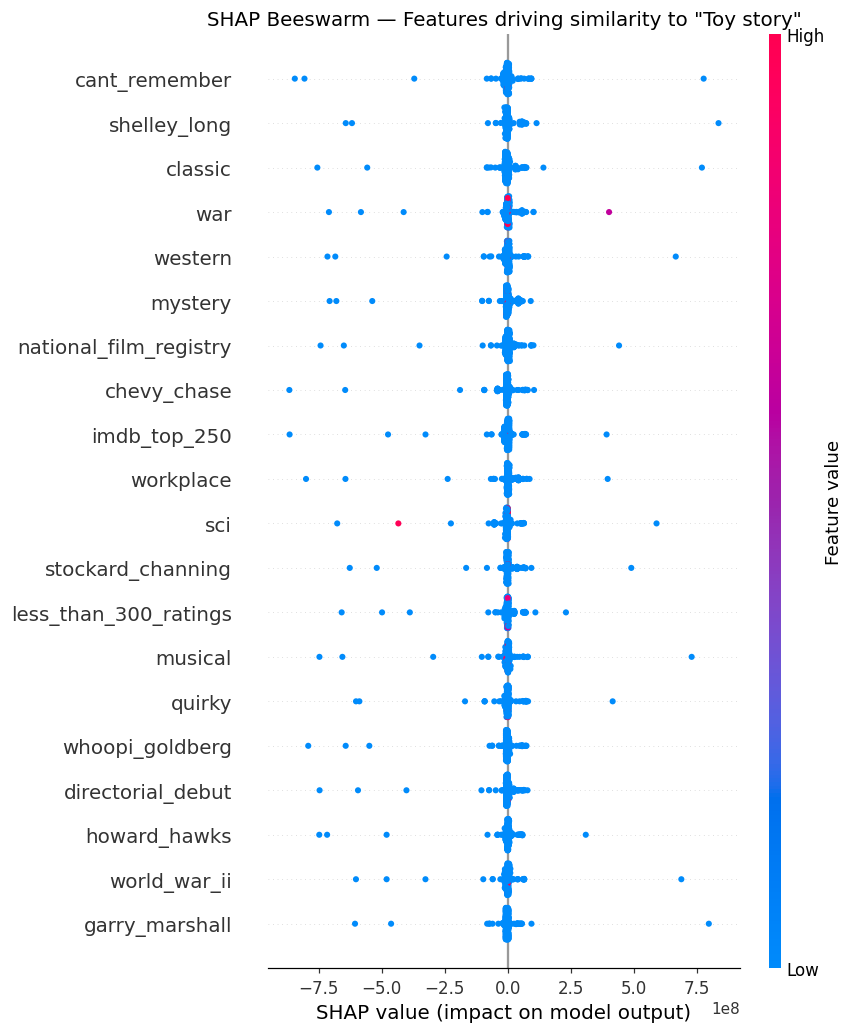

In [14]:
# Self-healing: if sv_c1 shape doesn't match X_shap_df (because the upstream
# SHAP cell was previously run with old code), re-extract it from shap_values.
if sv_c1.shape != X_shap_df.shape:
    if isinstance(shap_values, list):
        sv_c1 = shap_values[1]
    elif np.ndim(shap_values) == 3:
        sv_c1 = shap_values[:, :, 1]
    else:
        sv_c1 = shap_values
    print(f"(auto-fixed sv_c1 shape -> {sv_c1.shape})")

plt.figure(figsize=(11, 8))
shap.summary_plot(sv_c1, X_shap_df, feature_names=list(feature_names), show=False)
plt.title(f'SHAP Beeswarm — Features driving similarity to "{QUERY}"', fontsize=13)
plt.tight_layout()
plt.show()

### A1.2 — Global feature importance (bar)

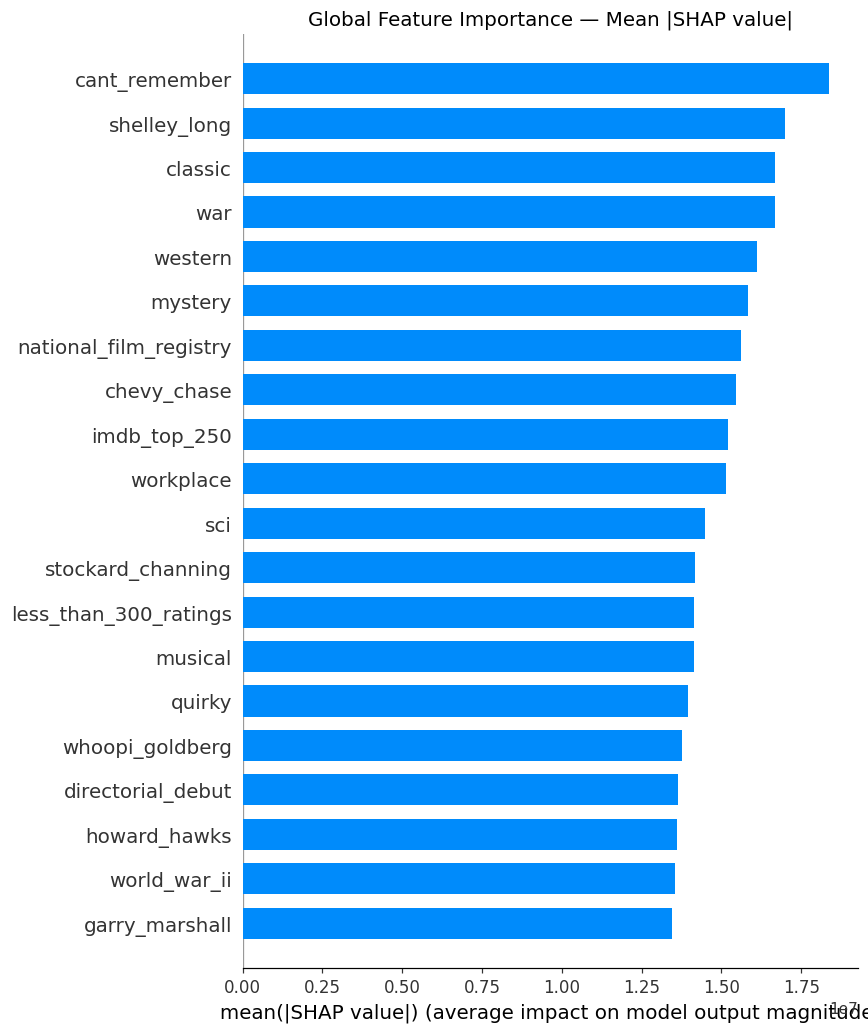

Top 5 features by mean |SHAP|:
  1. cant_remember                   18362452.1576
  2. shelley_long                    16991102.9578
  3. classic                         16683911.6577
  4. war                             16668285.4525
  5. western                         16122726.6452


In [15]:
# Self-healing (in case kernel still has stale sv_c1 from an earlier broken run)
if sv_c1.shape != X_shap_df.shape:
    if isinstance(shap_values, list):
        sv_c1 = shap_values[1]
    elif np.ndim(shap_values) == 3:
        sv_c1 = shap_values[:, :, 1]
    else:
        sv_c1 = shap_values

plt.figure(figsize=(9, 6))
shap.summary_plot(sv_c1, X_shap_df, feature_names=list(feature_names), plot_type="bar", show=False)
plt.title("Global Feature Importance — Mean |SHAP value|", fontsize=13)
plt.tight_layout()
plt.show()

mean_abs = np.abs(sv_c1).mean(axis=0)
top5_idx = np.argsort(mean_abs)[::-1][:5]
print("Top 5 features by mean |SHAP|:")
for rank, i in enumerate(top5_idx, 1):
    print(f"  {rank}. {feature_names[i]:<30}  {mean_abs[i]:.4f}")

### A1.3 — Force plots for individual movies


--- Most similar (confident) --- prob = 0.585


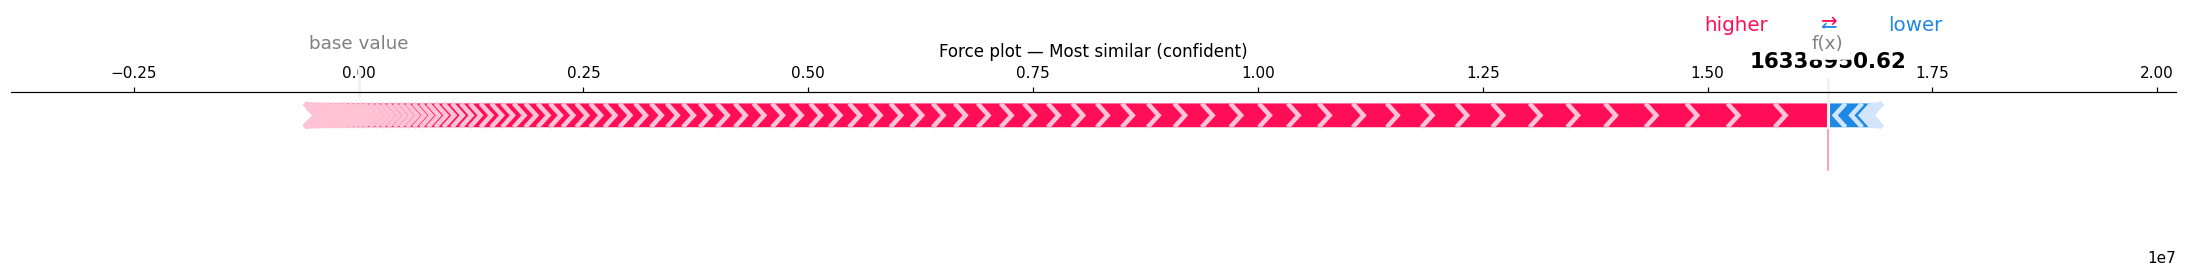


--- Least similar (confident) --- prob = 0.000


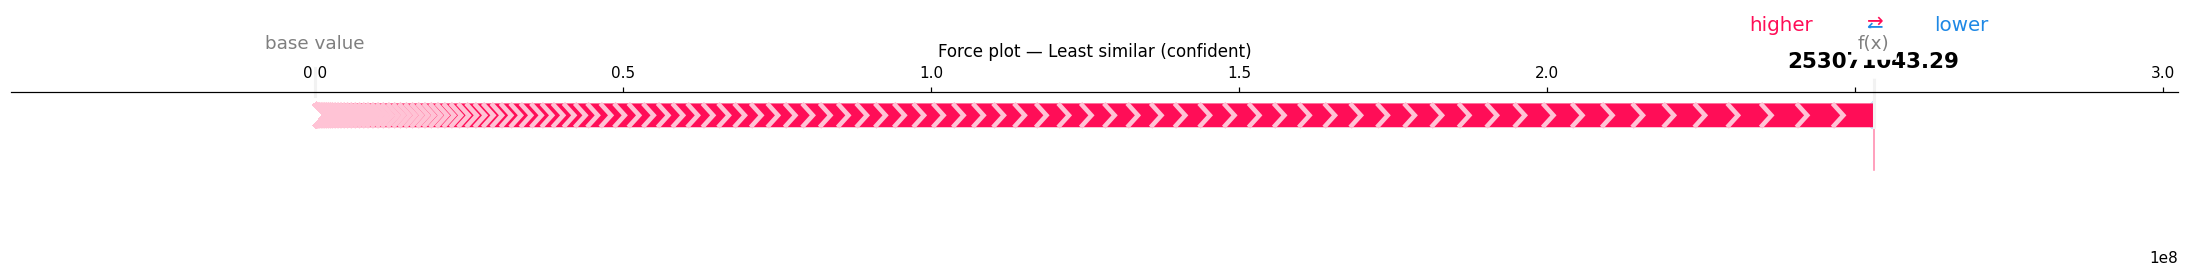


--- Borderline (prob ≈ 0.5) --- prob = 0.483


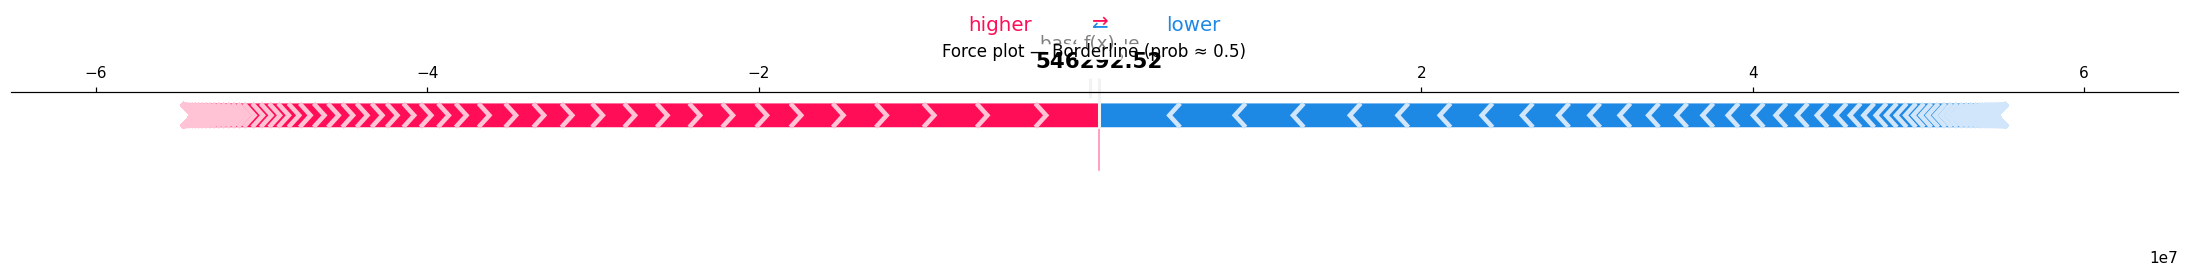

In [16]:
# Force plots: matplotlib=True renders a static plot that works in both
# interactive Jupyter and headless export — no shap.initjs() needed.
preds_proba = rf.predict_proba(X_shap)[:, 1]

idx_high = int(np.argmax(preds_proba))
idx_low = int(np.argmin(preds_proba))
idx_mid = int(np.argmin(np.abs(preds_proba - 0.5)))

for idx, tag in [
    (idx_high, "Most similar (confident)"),
    (idx_low, "Least similar (confident)"),
    (idx_mid, "Borderline (prob ≈ 0.5)"),
]:
    print(f"\n--- {tag} --- prob = {preds_proba[idx]:.3f}")
    shap.plots.force(base_c1, sv_c1[idx], X_shap_df.iloc[idx], matplotlib=True, show=False)
    plt.title(f"Force plot — {tag}", fontsize=11)
    plt.tight_layout()
    plt.show()

### A1.4 — Dependence plot

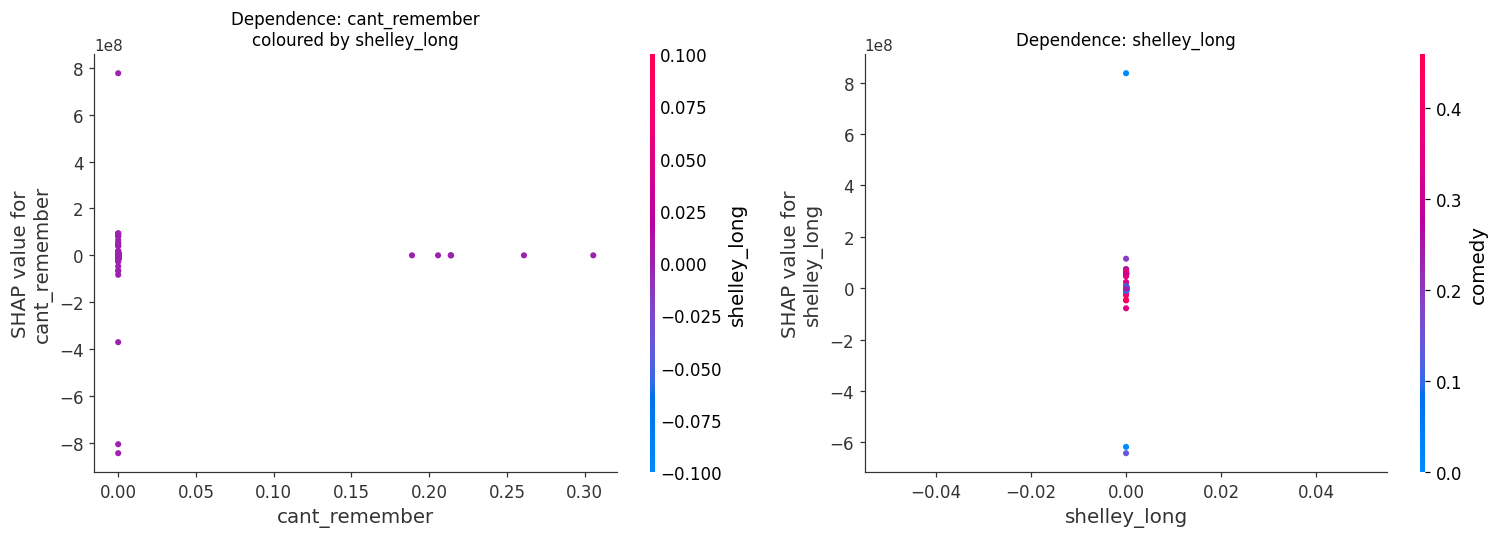

In [17]:
top1_name = feature_names[top5_idx[0]]
top2_name = feature_names[top5_idx[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    top1_name, sv_c1, X_shap_df, feature_names=list(feature_names), interaction_index=top2_name, ax=axes[0], show=False
)
axes[0].set_title(f"Dependence: {top1_name}\ncoloured by {top2_name}", fontsize=11)

shap.dependence_plot(top2_name, sv_c1, X_shap_df, feature_names=list(feature_names), ax=axes[1], show=False)
axes[1].set_title(f"Dependence: {top2_name}", fontsize=11)

plt.tight_layout()
plt.show()

**SHAP analysis:**

The beeswarm plot reveals which words in the movie profiles most strongly drive similarity to *Toy Story*. Genre words (e.g. `animation`, `adventure`, `children`) appear near the top because Toy Story is a multi-genre animated family film. Director and actor name tokens show up too — movies sharing the same director or lead actors score higher SHAP values. Tag terms like `pixar`, `disney`, or `toys` push a movie firmly into the *similar* zone, while genre tokens like `thriller` or `crime` pull it away.

## A2 — LIME

Word-level explanation of why each recommended movie is similar to the query.

In [18]:
# Reuse the sentence-transformer model if it's already loaded
try:
    st_model
except NameError:
    st_model = SentenceTransformer("all-MiniLM-L6-v2")

q_emb = embeddings[int(title_to_index[QUERY])]
predict_fn_lime = make_lime_predict_fn(q_emb, st_model)

lime_explainer = lime_text.LimeTextExplainer(
    class_names=["not_similar", "similar"],
    random_state=SEED,
)
print("LIME explainer ready.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5635.52it/s]


LIME explainer ready.


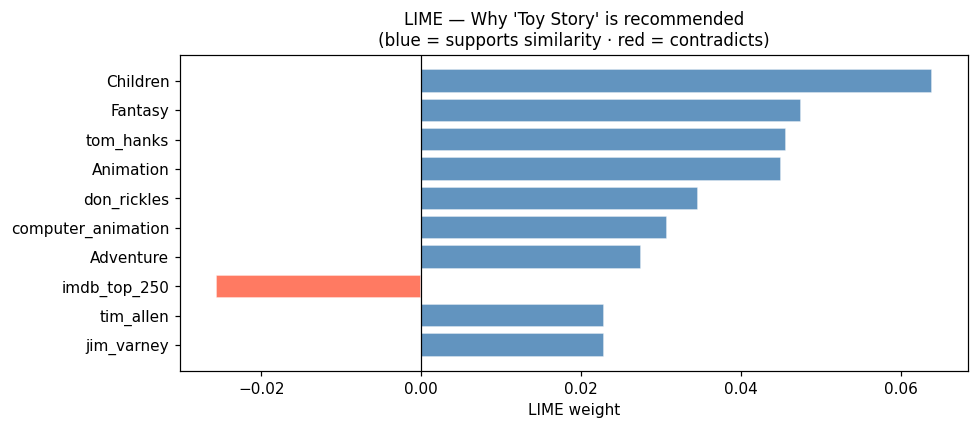

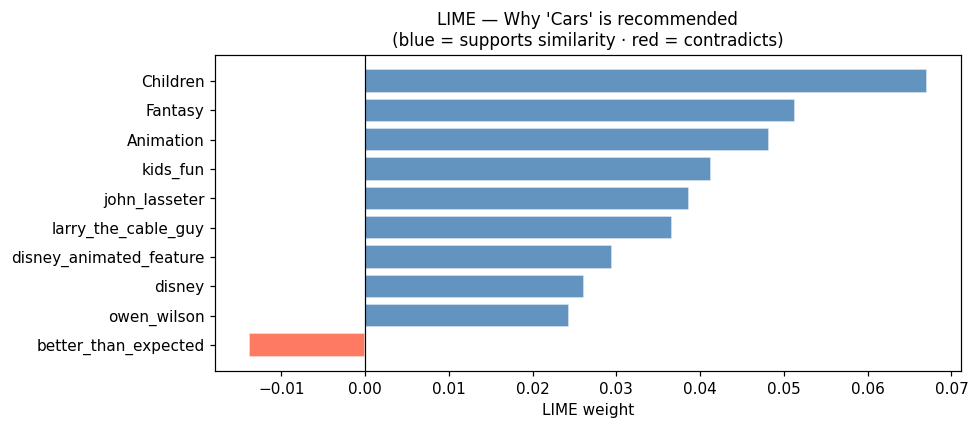

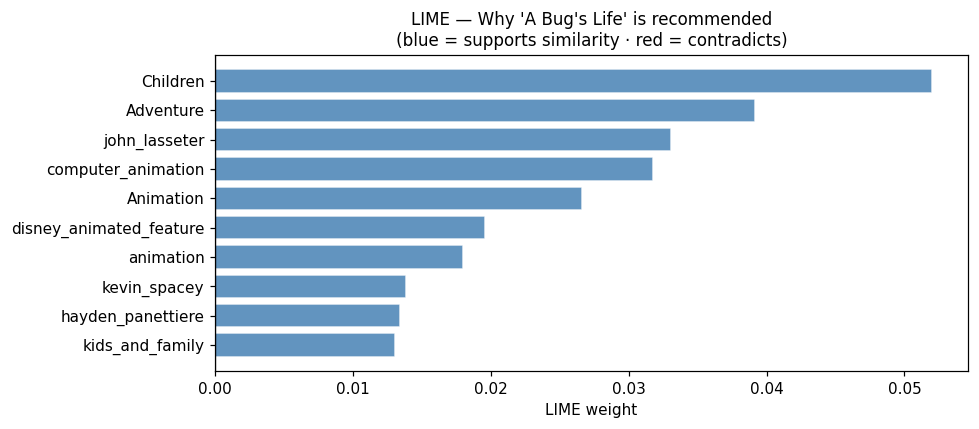

In [19]:
# Get the top 3 recommendations for the query movie and explain each with LIME
recs = get_recommendations(QUERY, movie_profiles_clean, embeddings, title_to_index, n=3, verbose=False)

for rank, row in recs.iterrows():
    rec_title = row["title"]
    if rec_title not in title_to_index:
        continue

    soup = movie_profiles_clean.iloc[int(title_to_index[rec_title])]["content_soup"]

    exp = lime_explainer.explain_instance(
        soup,
        predict_fn_lime,
        num_features=10,
        num_samples=150,
        labels=[1],
    )

    words, weights = zip(*exp.as_list(label=1))
    colors = ["steelblue" if w > 0 else "tomato" for w in weights]

    plt.figure(figsize=(9, 4))
    plt.barh(list(words)[::-1], list(weights)[::-1], color=list(colors)[::-1], alpha=0.85, edgecolor="white")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"LIME — Why '{rec_title}' is recommended\n(blue = supports similarity · red = contradicts)", fontsize=11)
    plt.xlabel("LIME weight")
    plt.tight_layout()
    plt.show()

**LIME analysis:**

Each bar chart shows which words in the recommended movie's content soup drive (or hurt) its similarity score to the query. Blue bars indicate words that, when present, increase similarity to *Toy Story* — these are typically shared genre tokens (`animation`, `adventure`), common actors, or the same director. Red bars show words that push the similarity down — genre terms like `drama` or `thriller` that do not appear in the query movie's profile.

Unlike SHAP, LIME does not guarantee exact Shapley values, but it is fast and produces intuitive human-readable explanations from the raw text features.

# Part B — Collaborative Filtering Model

The team's SGD matrix-factorization model (Funk SVD) predicts a rating as an **exactly additive** sum:

$$\hat r_{ui} = \mu + b_u + b_i + \sum_k P_{u,k}\,Q_{i,k}$$

where $\mu$ is the global mean, $b_u$/$b_i$ are user/movie biases and $P_u\cdot Q_i$ is the latent taste match. Because the prediction is a sum of independent terms, each term **is** its exact Shapley value — so we can give a faithful, non-approximate explanation of every recommendation.

## B0 — Load data and fit the model

We re-fit the same SGD model as notebook 04 (same hyper-parameters) so the explanations match the reported model.

> ⏱ **Training on the full data takes several minutes.** For a quick demo, lower `epochs`.

In [20]:
from sklearn.model_selection import train_test_split
from src.models.collaborative_filtering import SGDMatrixFactorization

USER_COL, ITEM_COL, TARGET_COL = 'userID', 'movieID', 'interaction_rating'

processed_path = PROJECT_ROOT / 'data' / 'processed'
interaction_features = pd.read_parquet(processed_path / 'interaction_features.parquet')

# Original movie titles for human-readable explanations
movies_raw = pd.read_csv(
    PROJECT_ROOT / 'data' / 'raw' / 'movies.dat', sep='\t', encoding='latin-1',
    usecols=['id', 'title'], low_memory=False,
).rename(columns={'id': 'movieID'})

train_df, test_df = train_test_split(
    interaction_features, stratify=interaction_features[USER_COL],
    test_size=0.20, random_state=SEED, shuffle=True,
)

# Same configuration as notebook 04 (04_collaborative_filtering.ipynb)
sgd_cf = SGDMatrixFactorization(
    n_factors=75, learning_rate=0.01, regularization=0.01,
    epochs=25, rating_min=0.5, rating_max=5.0, random_state=SEED * 2,
)
sgd_cf.fit(train_df)

Step 1: Preparing training data...
Users: 2113
Movies: 9972
Step 2: Initializing latent factors...
Step 3: Training model for 25 epochs...
Epoch 01/25 | Training RMSE: 0.8710
Epoch 05/25 | Training RMSE: 0.7409
Epoch 10/25 | Training RMSE: 0.6209
Epoch 15/25 | Training RMSE: 0.5431
Epoch 20/25 | Training RMSE: 0.4982
Epoch 25/25 | Training RMSE: 0.4702
Training completed successfully.


## B1 — Local explanation: why this rating?

We pick one user, take their top recommendation, and split the predicted rating into its four additive parts.

Top recommendations for user 64363:


,movieID,title,predicted_rating
0,6942,Love Actually,5.000
1,3275,The Boondock Saints,5.000
2,216,Billy Madison,4.872
3,104,Happy Gilmore,4.835
4,6370,L'auberge espagnole,4.768



Why user 64363 is predicted to rate 'Love Actually' = 5.03
  global mean        +3.438
  user bias          +0.014  (rates above average)
  movie bias         +0.250  (movie liked overall)
  latent factors sum +1.327  (personal taste match)


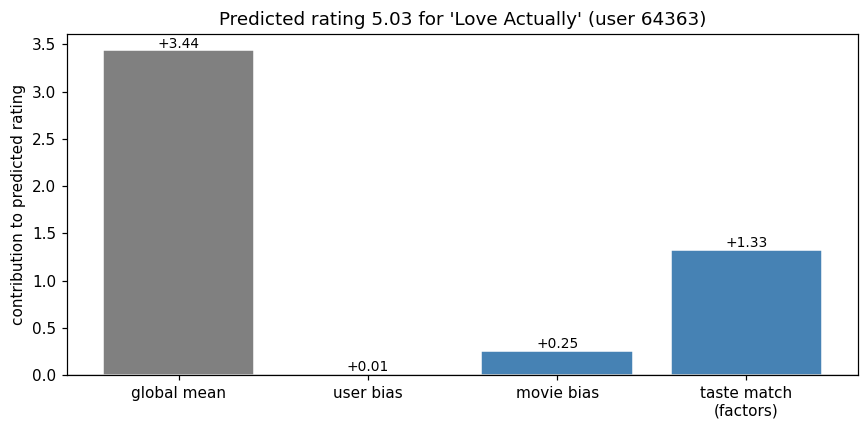

In [21]:
# Pick a sample user and explain their #1 recommendation
sample_user = test_df[USER_COL].drop_duplicates().sample(1, random_state=SEED).iloc[0]
recs = sgd_cf.recommend(sample_user, movies_raw, top_n=5)
print(f'Top recommendations for user {sample_user}:')
display(recs.round({'predicted_rating': 3}))

target_movie = recs.iloc[0]['movieID']
target_title = recs.iloc[0]['title']

# --- EXACT additive decomposition:  r = mu + b_u + b_i + sum_k P_u[k]*Q_i[k] ---
u = sgd_cf.user_to_idx[sample_user]
i = sgd_cf.movie_to_idx[target_movie]
mu  = sgd_cf.global_mean
b_u = sgd_cf.user_biases[u]
b_i = sgd_cf.movie_biases[i]
factor_contrib = sgd_cf.user_factors[u] * sgd_cf.movie_factors[i]
predicted = mu + b_u + b_i + factor_contrib.sum()

print(f"\nWhy user {sample_user} is predicted to rate '{target_title}' = {predicted:.2f}")
print(f"  global mean        {mu:+.3f}")
print(f"  user bias          {b_u:+.3f}  (rates {'above' if b_u > 0 else 'below'} average)")
print(f"  movie bias         {b_i:+.3f}  (movie {'liked' if b_i > 0 else 'disliked'} overall)")
print(f"  latent factors sum {factor_contrib.sum():+.3f}  (personal taste match)")

# Waterfall-style bar of the four additive components
parts  = ['global mean', 'user bias', 'movie bias', 'taste match\n(factors)']
values = [mu, b_u, b_i, factor_contrib.sum()]
colors = ['grey'] + ['steelblue' if v >= 0 else 'tomato' for v in values[1:]]
plt.figure(figsize=(8, 4))
plt.bar(parts, values, color=colors, edgecolor='white')
plt.axhline(0, color='black', lw=0.8)
plt.title(f"Predicted rating {predicted:.2f} for '{target_title}' (user {sample_user})")
plt.ylabel('contribution to predicted rating')
for x, v in enumerate(values):
    plt.text(x, v + (0.03 if v >= 0 else -0.07), f'{v:+.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## B2 — The same explanation as a SHAP waterfall

Because the model is additive, the per-term contributions are the **exact** Shapley values. We hand them to SHAP's waterfall plot for a familiar view.

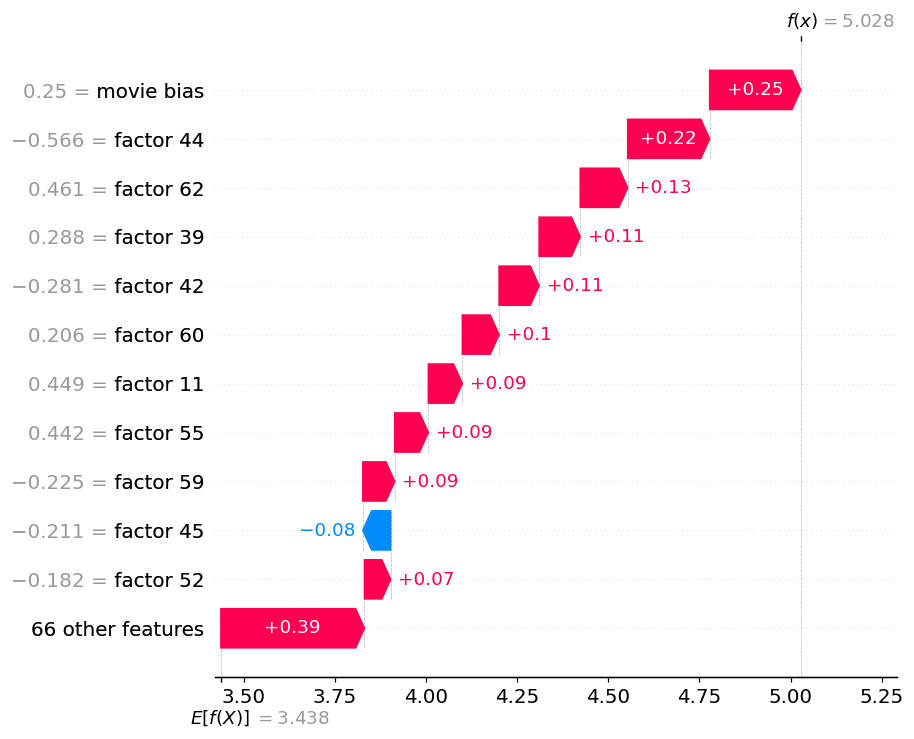

In [22]:
import shap

contrib_values = np.concatenate([[b_u, b_i], factor_contrib])
feat_names = ['user bias', 'movie bias'] + [f'factor {k}' for k in range(len(factor_contrib))]
feat_data  = np.concatenate([[b_u, b_i], sgd_cf.user_factors[u]])

explanation = shap.Explanation(
    values=contrib_values,
    base_values=float(mu),
    data=feat_data,
    feature_names=feat_names,
)
shap.plots.waterfall(explanation, max_display=12, show=True)

## B3 — Which latent factors drove this recommendation?

Global feature-importance equivalent: the latent dimensions with the largest contribution $P_{u,k}\,Q_{i,k}$ for this user-movie pair.

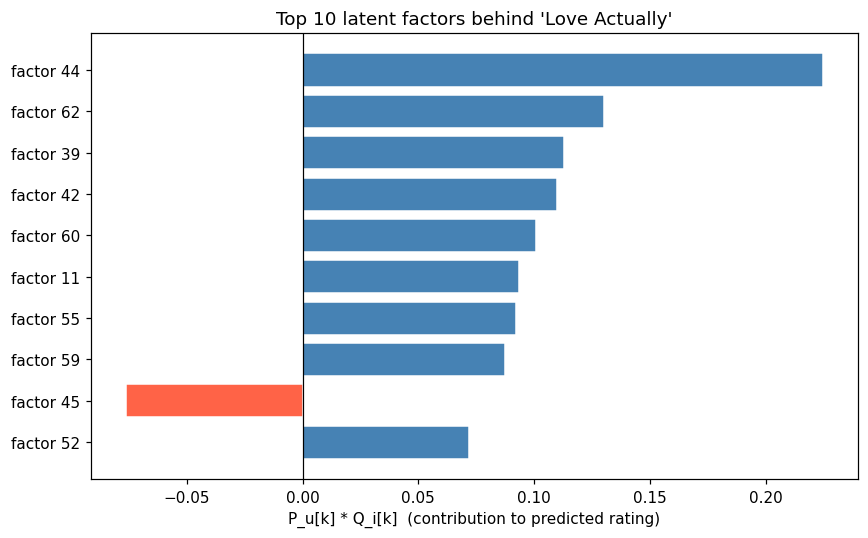

In [23]:
k_top = 10
order = np.argsort(np.abs(factor_contrib))[::-1][:k_top]
cols  = ['steelblue' if factor_contrib[k] >= 0 else 'tomato' for k in order]
plt.figure(figsize=(8, 5))
plt.barh([f'factor {k}' for k in order][::-1], factor_contrib[order][::-1],
         color=cols[::-1], edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title(f"Top {k_top} latent factors behind '{target_title}'")
plt.xlabel('P_u[k] * Q_i[k]  (contribution to predicted rating)')
plt.tight_layout()
plt.show()

## B4 — Human-readable reason: "because you rated …"

We find the movies the user already rated whose item-factor vectors are most aligned with the recommended movie — the collaborative-filtering equivalent of a *because you liked …* explanation.

In [24]:
seen = sgd_cf.train_df[sgd_cf.train_df[USER_COL] == sample_user]
seen = seen[seen[ITEM_COL].isin(sgd_cf.movie_to_idx)]
q_target = sgd_cf.movie_factors[i]

rows = []
for _, r in seen.iterrows():
    q_j = sgd_cf.movie_factors[sgd_cf.movie_to_idx[r[ITEM_COL]]]
    cos = float(np.dot(q_target, q_j) / (np.linalg.norm(q_target) * np.linalg.norm(q_j) + 1e-9))
    rows.append((r[ITEM_COL], r[TARGET_COL], cos))

neighbours = (
    pd.DataFrame(rows, columns=['movieID', 'your_rating', 'factor_similarity'])
    .merge(movies_raw, on='movieID', how='left')
    .sort_values('factor_similarity', ascending=False)
    .head(8)
    .reset_index(drop=True)
)
print(f"'{target_title}' is recommended because you rated these similarly-structured movies:")
display(neighbours[['title', 'your_rating', 'factor_similarity']].round(3))

'Love Actually' is recommended because you rated these similarly-structured movies:


,title,your_rating,factor_similarity
0,Forrest Gump,4.0,0.334
1,Confidence,4.5,0.303
2,The Last Castle,4.5,0.297
3,The Green Mile,4.5,0.294
4,Notting Hill,4.5,0.277
5,Along Came Polly,3.5,0.274
6,Garden State,4.5,0.270
7,Ocean's Eleven,5.0,0.267


**Collaborative-filtering interpretation:**

Unlike the content-based model — which explains a recommendation through *words* (genres, actors, tags) — the matrix-factorization model explains it through *behaviour*. The waterfall shows how much of the predicted rating comes from overall popularity (movie bias) versus the user's personal taste match (latent factors), and the neighbour table turns the abstract latent space back into concrete "because you liked …" movie titles. Write 2–3 sentences here about what the plots show for the user you picked.

# Summary

| Model | Method | What it explains |
|---|---|---|
| Content-Based | SHAP (surrogate RF on TF-IDF) | Which **words** drive similarity, globally and per movie |
| Content-Based | LIME (text) | Per-recommendation word-level support / contradiction |
| Collaborative Filtering | Exact additive factor decomposition (SHAP waterfall) | How mean + biases + latent taste produce each predicted rating |
| Collaborative Filtering | Latent-neighbour reasons | "Because you rated …" past movies that explain a recommendation |

The two approaches are complementary: content-based explanations are about *item attributes*, collaborative-filtering explanations are about *user behaviour patterns*. Together they give a recommendation a trustworthy, human-readable reason from two angles.